# **News Category**

---

News headline categorization with fine-tuned DistilBERT, BiLSTM, Logistic Regression, and Naive Bayes.

## **Taxonomy**

---

Applies versioned category merges to the base split. Each version section relabels fresh copies of the base and writes its own folder, so versions are independent and rows stay identical to the base.

Outputs (per version, under `data/processed/<version>/`):

- `train.parquet`: training split with merged categories

- `test.parquet`: held-out split with merged categories

- `labels.json`: merged category list

- `category_merge_map.json`: the merge decision that produced this version

### **Setup**

---

#### **Config**


In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from bigtree import list_to_tree, hyield_tree
from pathlib import Path
from news_category.display import show

pd.set_option("display.max_rows", 100)
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.titlesize"] = 16
plt.rcParams["figure.titleweight"] = "bold"

RANDOM_STATE = 42

FILE_RAW = Path("data/raw/News_Category_Dataset_v3.json")
DIR_PROCESSED = Path("data/processed")
DIR_PROCESSED.mkdir(parents=True, exist_ok=True)

# default df.head() to 10 rows
_orig_head = pd.DataFrame.head
pd.DataFrame.head = lambda self, n=10: _orig_head(self, n)

#### **Helper**

Plotting helpers reused by the base and every version.


In [2]:
def plot_distribution(df_train: pd.DataFrame, df_test: pd.DataFrame, title: str) -> None:
  df_counts = pd.concat(
    {"train": df_train["category"].value_counts(), "test": df_test["category"].value_counts()},
    axis=1,
  ).sort_values("train", ascending=False)
  fig, axes = plt.subplots(1, 2, figsize=(16, 8))
  for ax, split in zip(axes, ["train", "test"]):
    df_counts[split].plot.pie(ax=ax, ylabel="", title=split, autopct="%1.1f%%", pctdistance=0.9, textprops={"size": 8})
    ax.text(0, 0, f"{df_counts[split].count()}\ncategories", ha="center", va="center", fontweight="bold")
  plt.suptitle(title)
  plt.tight_layout()
  plt.show()


def lineage_of(version: str, registry: dict) -> list:
  chain = []
  while version is not None:
    entry = registry[version]
    chain.append((version, entry["labels"], entry["merges"]))
    version = entry["parent"]
  return chain[::-1]


def plot_merge_tree(lineage: list) -> None:
  # categories touched by a merge at any layer, as a source or a target
  involved = set()
  for _, _, merges in lineage[1:]:
    involved |= set(merges) | set(merges.values())

  # each involved base category's full path: <version> / final / ... / base
  version = lineage[-1][0]
  finals = {}
  for cat in lineage[0][1]:
    chain = [cat]
    for _, _, merges in lineage[1:]:
      chain.append(merges.get(chain[-1], chain[-1]))
    if involved.intersection(chain):
      finals.setdefault(chain[-1], []).append(list(reversed(chain)))

  # merged buckets (more than one source) first, so they cluster at the top
  paths = []
  for final in sorted(finals, key=lambda f: (len(finals[f]) == 1, f)):
    for chain in finals[final]:
      paths.append("/".join([version, *chain]))

  root = list_to_tree(paths)
  tree = "\n".join(hyield_tree(root, style="rounded"))
  show(f"Category Merges ({version})", tree)

### **Base**

---

#### **Load**


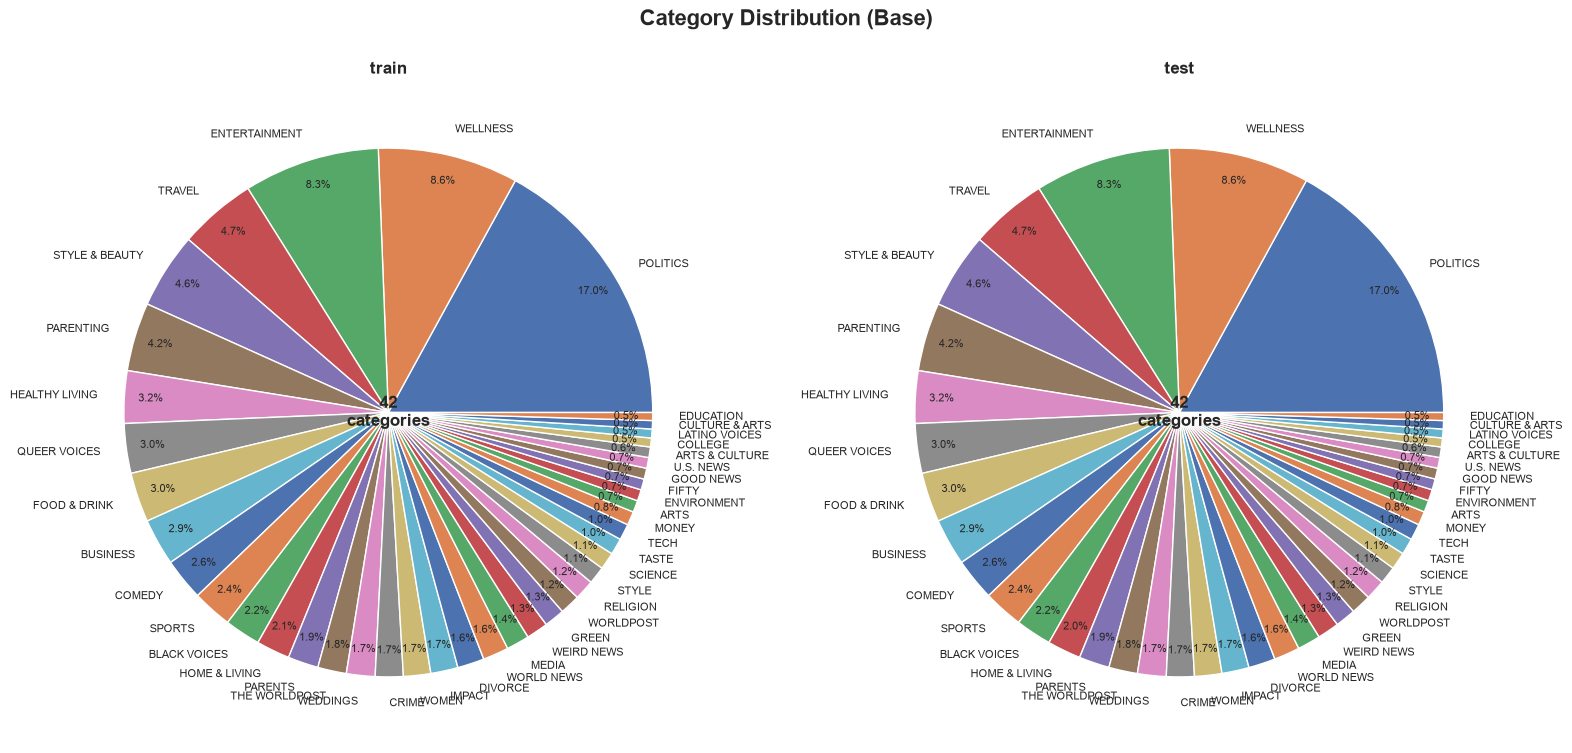

In [3]:
DIR_BASE = DIR_PROCESSED / "base"
df_base_train = pd.read_parquet(DIR_BASE / "train.parquet")
df_base_test = pd.read_parquet(DIR_BASE / "test.parquet")
df_base = pd.concat([df_base_train, df_base_test], ignore_index=True)

with open(DIR_BASE / "labels.json") as f:
  base_labels = json.load(f)

registry = {
  "base": {
    "train": df_base_train,
    "test": df_base_test,
    "labels": base_labels,
    "merges": {},
    "parent": None,
  }
}
plot_distribution(df_base_train, df_base_test, "Category Distribution (Base)")

#### **Counts By Year**

A rename appears as one category ending as another begins.


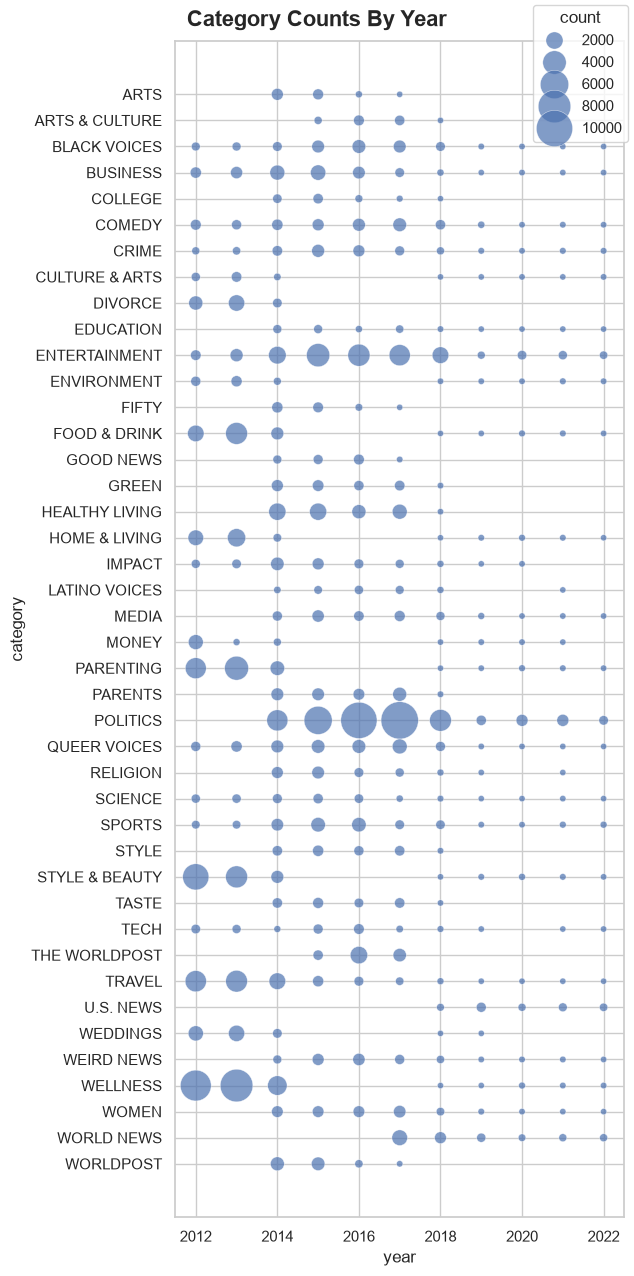

In [4]:
df_year_counts = df_base.assign(year=df_base["date"].dt.year).groupby(["category", "year"]).size().reset_index(name="count")
df_year_counts["category"] = pd.Categorical(
  df_year_counts["category"], categories=sorted(df_year_counts["category"].unique()), ordered=True
)
fig, ax = plt.subplots(figsize=(6.5, 13))
sns.scatterplot(data=df_year_counts, x="year", y="category", size="count", sizes=(20, 720), alpha=0.7, ax=ax)
fig.suptitle("Category Counts By Year")
legend = ax.legend(loc="upper right", bbox_to_anchor=(0.99, 0.99), bbox_transform=fig.transFigure, title="count")
legend.set_in_layout(False)
plt.tight_layout()

#### **Trends**

Monthly counts for suspected clusters. A rename shows one area fading as another rises.


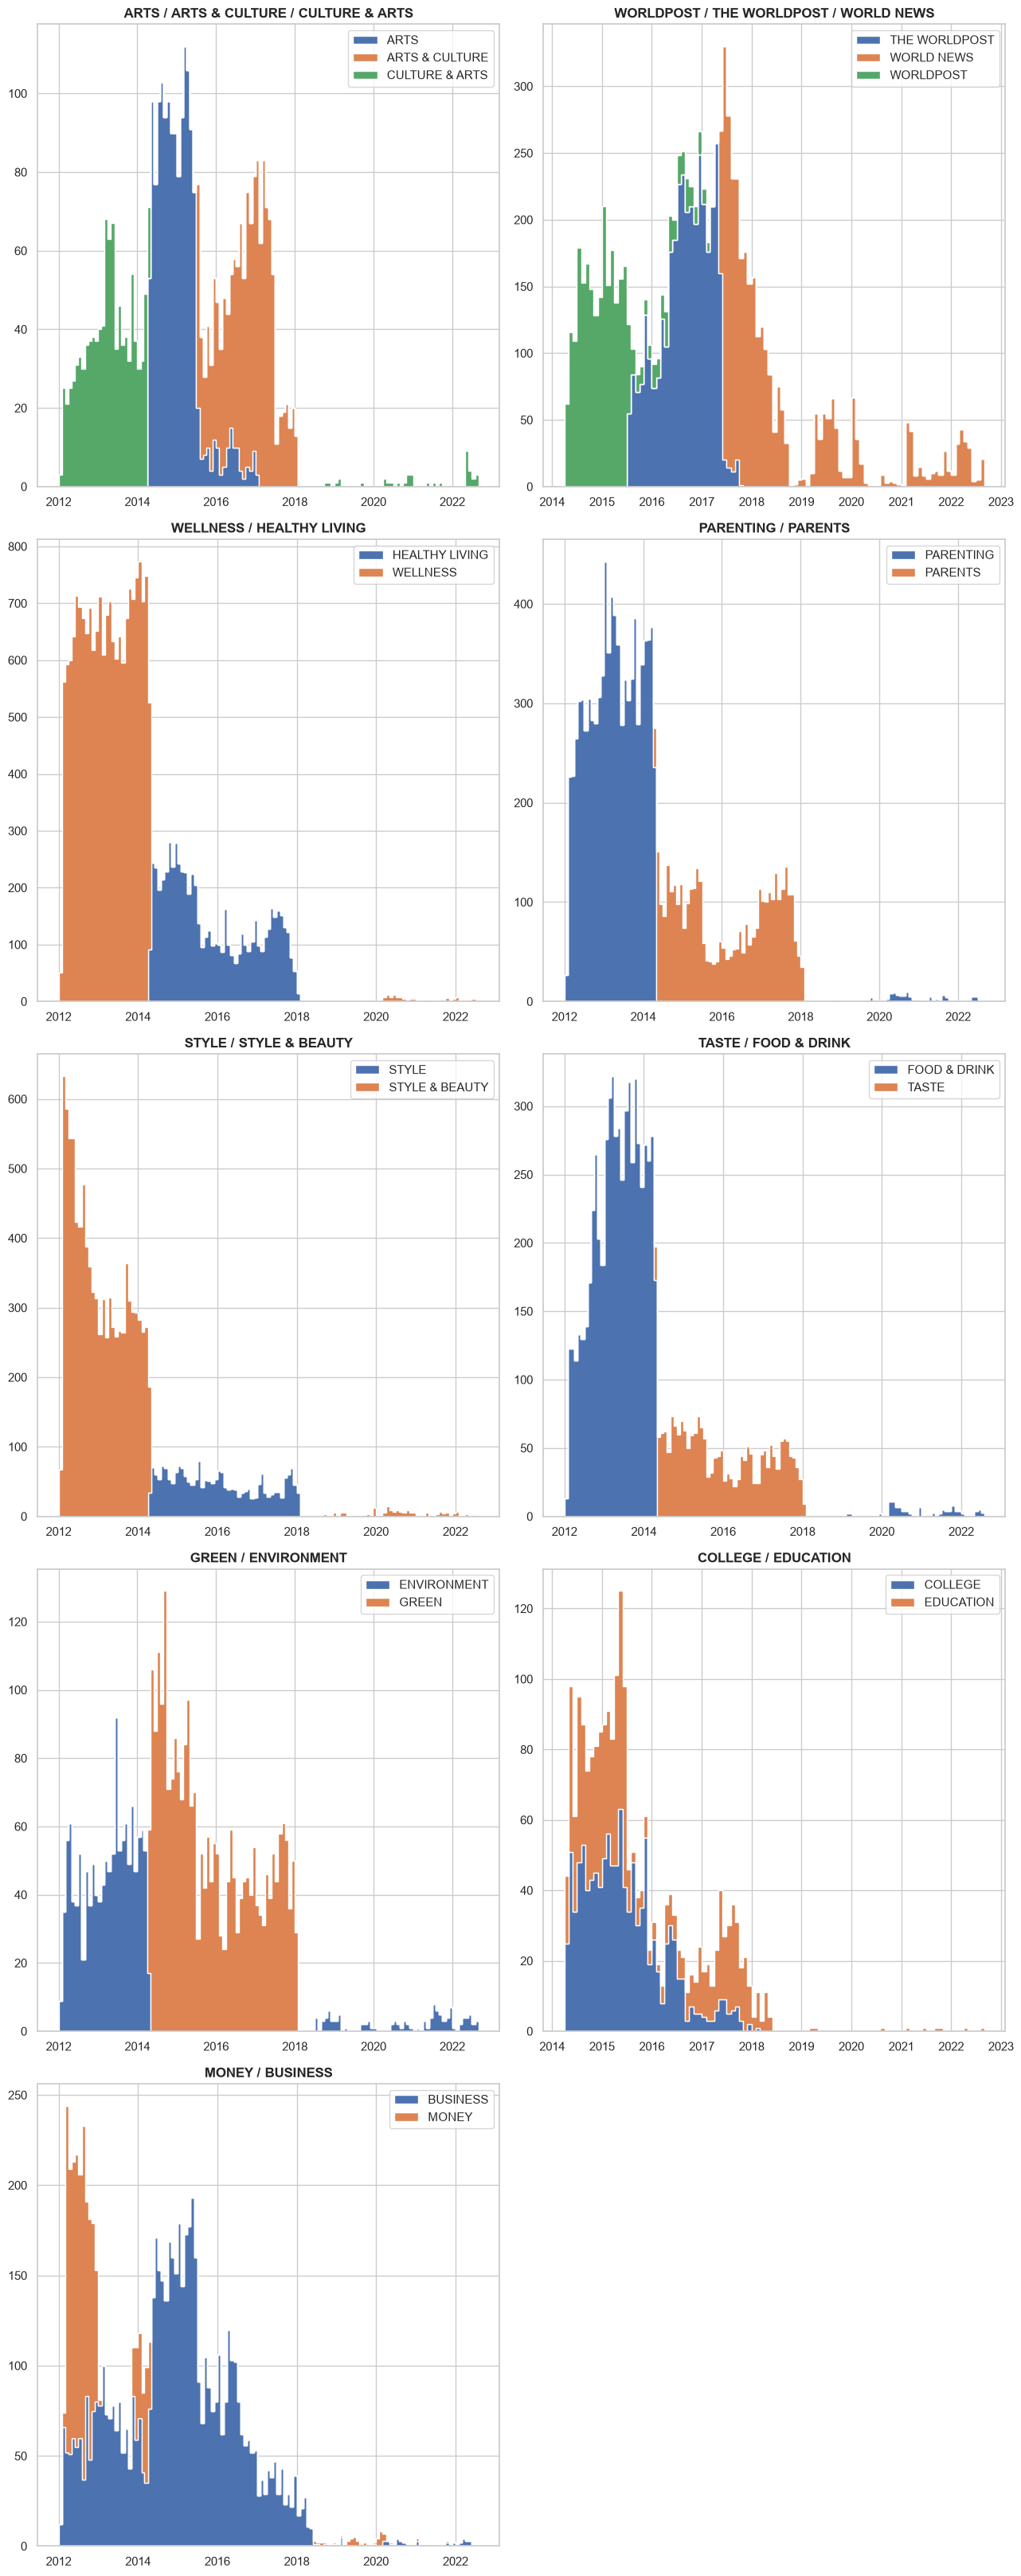

In [5]:
def plot_category_trend(cats: list[str], ax: plt.Axes | None = None) -> None:
  if ax is None:
    _, ax = plt.subplots()
  sub = df_base[df_base["category"].isin(cats)]
  monthly = pd.crosstab(sub["date"], sub["category"]).resample("MS").sum()
  ax.stackplot(monthly.index, monthly.T, labels=monthly.columns, step="post")
  ax.legend(loc="upper right")
  ax.set_title(" / ".join(cats))


clusters = [
  ["ARTS", "ARTS & CULTURE", "CULTURE & ARTS"],
  ["WORLDPOST", "THE WORLDPOST", "WORLD NEWS"],
  ["WELLNESS", "HEALTHY LIVING"],
  ["PARENTING", "PARENTS"],
  ["STYLE", "STYLE & BEAUTY"],
  ["TASTE", "FOOD & DRINK"],
  ["GREEN", "ENVIRONMENT"],
  ["COLLEGE", "EDUCATION"],
  ["MONEY", "BUSINESS"],
]
ncols = min(2, len(clusters))
nrows = (len(clusters) + ncols - 1) // ncols
fig, _ = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 6.5 * nrows))
for i, ax in enumerate(fig.axes):
  if i < len(clusters):
    plot_category_trend(clusters[i], ax=ax)
  else:
    ax.set_visible(False)  # hide unused cells
plt.tight_layout()

### **v1**

---

#### **Definition**

Delta on the parent: clean renames confirmed by the trends above; ambiguous pairs (COLLEGE / EDUCATION, MONEY / BUSINESS, FIFTY) are deferred.


In [6]:
VERSION = "v1"
PARENT = "base"
CATEGORY_MERGES = {
  "ARTS": "ARTS & CULTURE",
  "CULTURE & ARTS": "ARTS & CULTURE",
  "THE WORLDPOST": "WORLD NEWS",
  "WORLDPOST": "WORLD NEWS",
  "HEALTHY LIVING": "WELLNESS",
  "PARENTS": "PARENTING",
  "STYLE": "STYLE & BEAUTY",
  "TASTE": "FOOD & DRINK",
  "GREEN": "ENVIRONMENT",
}

absent = set(CATEGORY_MERGES) - set(registry[PARENT]["labels"])
assert not absent, f"unknown merge sources: {absent}"

categories = sorted({CATEGORY_MERGES.get(c, c) for c in registry[PARENT]["labels"]})
registry[VERSION] = {"labels": categories, "merges": CATEGORY_MERGES, "parent": PARENT}
plot_merge_tree(lineage_of(VERSION, registry))

── Category Merges (v1) ────────────────────
                         ╭─      ARTS
      ╭─ ARTS & CULTURE ─┼─ ARTS & CULTURE
      │                  ╰─ CULTURE & ARTS
      │                  ╭─  ENVIRONMENT
      ├─  ENVIRONMENT   ─┤
      │                  ╰─     GREEN
      │                  ╭─  FOOD & DRINK
      ├─  FOOD & DRINK  ─┤
      │                  ╰─     TASTE
      │                  ╭─   PARENTING
─ v1 ─┼─   PARENTING    ─┤
      │                  ╰─    PARENTS
      │                  ╭─     STYLE
      ├─ STYLE & BEAUTY ─┤
      │                  ╰─ STYLE & BEAUTY
      │                  ╭─ HEALTHY LIVING
      ├─    WELLNESS    ─┤
      │                  ╰─    WELLNESS
      │                  ╭─ THE WORLDPOST
      ╰─   WORLD NEWS   ─┼─   WORLD NEWS
                         ╰─   WORLDPOST


#### **Merge**

Apply the merges to the parent split, register the version, and plot the tree and distribution.


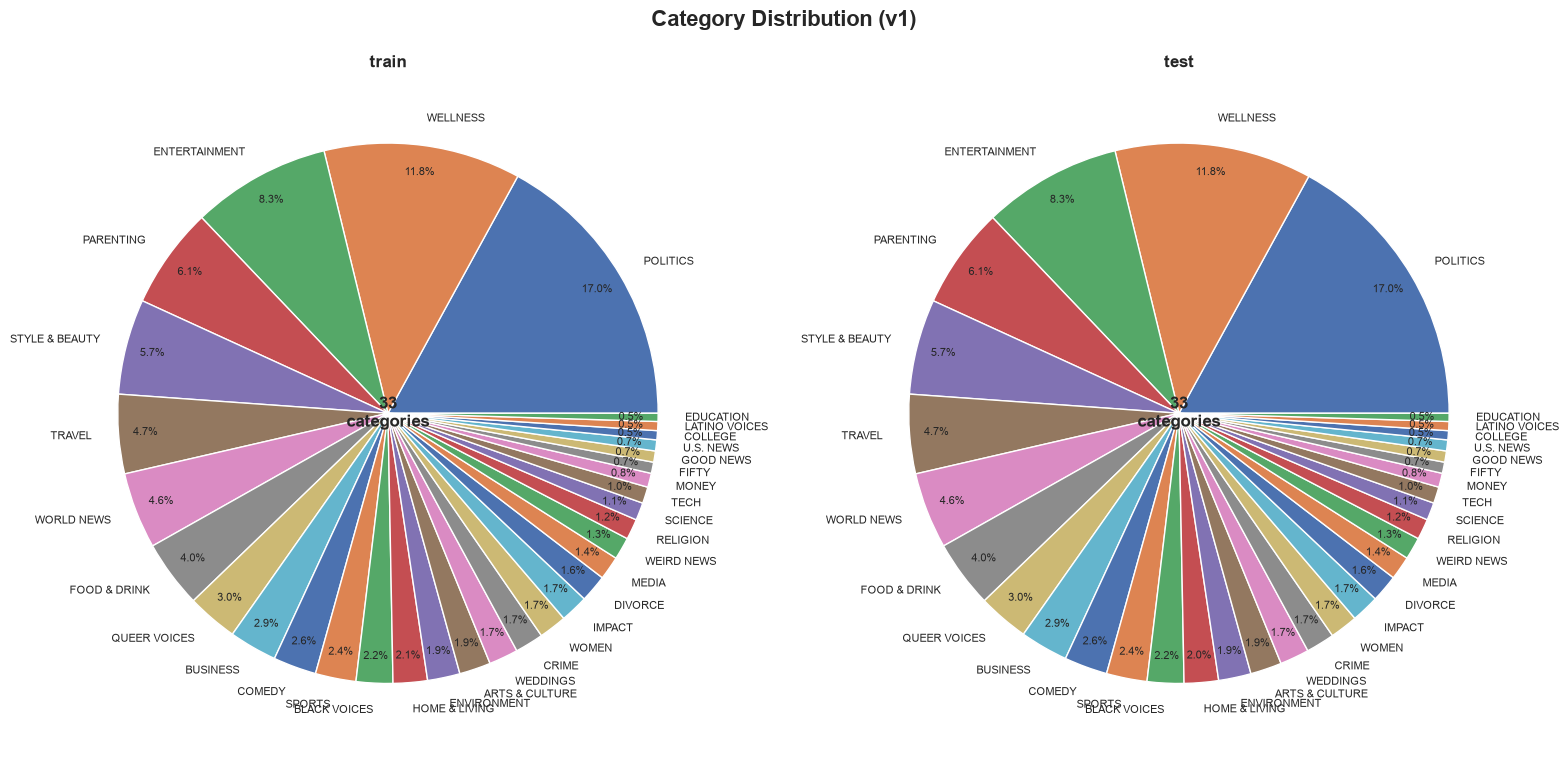

In [7]:
parent = registry[PARENT]
df_train = parent["train"].assign(category=parent["train"]["category"].replace(CATEGORY_MERGES))
df_test = parent["test"].assign(category=parent["test"]["category"].replace(CATEGORY_MERGES))
registry[VERSION]["train"] = df_train
registry[VERSION]["test"] = df_test
plot_distribution(df_train, df_test, f"Category Distribution ({VERSION})")

#### **Output**

Write the version's dataset, label list, and merge map.


In [8]:
DIR_OUT = DIR_PROCESSED / VERSION
DIR_OUT.mkdir(parents=True, exist_ok=True)
df_train.to_parquet(DIR_OUT / "train.parquet", index=False)
df_test.to_parquet(DIR_OUT / "test.parquet", index=False)
with open(DIR_OUT / "labels.json", "w") as f:
  json.dump(categories, f, indent=2)
with open(DIR_OUT / "category_merge_map.json", "w") as f:
  json.dump(CATEGORY_MERGES, f, indent=2, sort_keys=True)
show(f"Categories ({VERSION})", np.array2string(np.array(categories), max_line_width=100, separator=", "))

── Categories (v1) ─────────────────────────
['ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME', 'DIVORCE', 'EDUCATION',
 'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK', 'GOOD NEWS', 'HOME & LIVING', 'IMPACT',
 'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE',
 'SPORTS', 'STYLE & BEAUTY', 'TECH', 'TRAVEL', 'U.S. NEWS', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS',
 'WOMEN', 'WORLD NEWS']
